In [1]:
import os, time, random, math
from dataclasses import dataclass
from typing import List, Dict, Tuple, Set

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, QED
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

DATA_PATH = "./cache_qm9/qm9_splits_vocab.pt"  
obj = torch.load(DATA_PATH)
train_sm, val_sm, test_sm = obj["splits"]
stoi, itos = obj["stoi"], obj["itos"]

PAD, BOS, EOS = "<PAD>", "<BOS>", "<EOS>"
pad_id = stoi[PAD]
bos_id = stoi[BOS]
eos_id = stoi[EOS]
vocab_size = len(itos)

print("Loaded:", len(train_sm), len(val_sm), len(test_sm), "Vocab:", vocab_size)


Device: cuda
Loaded: 120496 6694 6695 Vocab: 24


In [2]:
MAX_LEN = 80

def encode(sm: str, stoi: Dict[str,int], max_len: int) -> List[int]:
    ids = [stoi[BOS]] + [stoi[c] for c in sm] + [stoi[EOS]]
    if len(ids) < max_len:
        ids = ids + [stoi[PAD]] * (max_len - len(ids))
    else:
        ids = ids[:max_len]
        ids[-1] = stoi[EOS]
    return ids

class SmilesVAEDataset(Dataset):
    def __init__(self, smiles_list: List[str], stoi: Dict[str,int], max_len: int):
        self.smiles = smiles_list
        self.stoi = stoi
        self.max_len = max_len

    def __len__(self):
        return len(self.smiles)

    def __getitem__(self, idx):
        ids = encode(self.smiles[idx], self.stoi, self.max_len)
        return torch.tensor(ids, dtype=torch.long)

train_ds = SmilesVAEDataset(train_sm, stoi, MAX_LEN)
val_ds   = SmilesVAEDataset(val_sm, stoi, MAX_LEN)

BATCH_SIZE = 256 if DEVICE=="cuda" else 128
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=(DEVICE=="cuda"))
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=(DEVICE=="cuda"))

print("Batches:", len(train_loader), len(val_loader))


Batches: 471 27


In [3]:
def to_mol(smiles: str):
    return Chem.MolFromSmiles(smiles)

def canonical(smiles: str) -> str | None:
    m = to_mol(smiles)
    if m is None:
        return None
    return Chem.MolToSmiles(m)

train_canon: Set[str] = set()
for s in train_sm:
    cs = canonical(s)
    if cs is not None:
        train_canon.add(cs)

def validity(smiles_list: List[str]) -> Tuple[float, List[str]]:
    valid_canon = []
    for s in smiles_list:
        cs = canonical(s)
        if cs is not None:
            valid_canon.append(cs)
    return len(valid_canon) / max(1, len(smiles_list)), valid_canon

def uniqueness(valid_canon: List[str]) -> float:
    return 0.0 if len(valid_canon)==0 else len(set(valid_canon))/len(valid_canon)

def novelty(valid_canon: List[str], train_set: Set[str]) -> float:
    return 0.0 if len(valid_canon)==0 else sum(1 for s in valid_canon if s not in train_set)/len(valid_canon)

def compute_properties(valid_canon: List[str]) -> Dict[str,float]:
    if len(valid_canon)==0:
        return {"mw_mean": math.nan, "logp_mean": math.nan, "qed_mean": math.nan}
    mws, logps, qeds = [], [], []
    for s in valid_canon:
        m = to_mol(s)
        if m is None:
            continue
        mws.append(Descriptors.MolWt(m))
        logps.append(Crippen.MolLogP(m))
        qeds.append(QED.qed(m))
    if len(mws)==0:
        return {"mw_mean": math.nan, "logp_mean": math.nan, "qed_mean": math.nan}
    return {"mw_mean": float(np.mean(mws)), "logp_mean": float(np.mean(logps)), "qed_mean": float(np.mean(qeds))}

def evaluate_smiles(samples: List[str], train_set: Set[str]) -> Dict[str,float]:
    v, valid_canon = validity(samples)
    out = {
        "n_samples": len(samples),
        "validity": v,
        "n_valid": len(valid_canon),
        "uniqueness": uniqueness(valid_canon),
        "novelty": novelty(valid_canon, train_set),
    }
    out.update(compute_properties(valid_canon))
    return out


In [4]:
@dataclass
class VAEConfig:
    vocab_size: int
    emb_dim: int = 256
    enc_hidden: int = 512
    dec_hidden: int = 512
    num_layers: int = 1
    z_dim: int = 64
    dropout: float = 0.0

class SmilesVAE(nn.Module):
    def __init__(self, cfg: VAEConfig, pad_id: int, bos_id: int, eos_id: int):
        super().__init__()
        self.cfg = cfg
        self.pad_id = pad_id
        self.bos_id = bos_id
        self.eos_id = eos_id

        self.embed = nn.Embedding(cfg.vocab_size, cfg.emb_dim, padding_idx=pad_id)

        self.enc_gru = nn.GRU(cfg.emb_dim, cfg.enc_hidden, num_layers=cfg.num_layers,
                              batch_first=True, dropout=cfg.dropout if cfg.num_layers > 1 else 0.0)

        self.to_mu = nn.Linear(cfg.enc_hidden, cfg.z_dim)
        self.to_logvar = nn.Linear(cfg.enc_hidden, cfg.z_dim)

        self.z_to_h0 = nn.Linear(cfg.z_dim, cfg.dec_hidden * cfg.num_layers)

        self.dec_gru = nn.GRU(cfg.emb_dim, cfg.dec_hidden, num_layers=cfg.num_layers,
                              batch_first=True, dropout=cfg.dropout if cfg.num_layers > 1 else 0.0)

        self.fc_out = nn.Linear(cfg.dec_hidden, cfg.vocab_size)

    def encode(self, x):
        emb = self.embed(x)
        _, h = self.enc_gru(emb)
        h_last = h[-1]
        return self.to_mu(h_last), self.to_logvar(h_last)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z, x_in):
        B = z.size(0)
        L = self.cfg.num_layers
        h0 = self.z_to_h0(z).view(L, B, self.cfg.dec_hidden).contiguous()
        emb = self.embed(x_in)
        out, _ = self.dec_gru(emb, h0)
        return self.fc_out(out)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_in = x[:, :-1]
        x_tgt = x[:, 1:]
        logits = self.decode(z, x_in)
        return logits, x_tgt, mu, logvar

def kl_divergence(mu, logvar):
    return 0.5 * torch.sum(torch.exp(logvar) + mu**2 - 1.0 - logvar, dim=1)

def recon_loss(logits, targets, pad_id: int):
    B, T, V = logits.shape
    return F.cross_entropy(logits.reshape(B*T, V), targets.reshape(B*T), ignore_index=pad_id)


In [9]:
def run_epoch(vae: SmilesVAE, loader, optimizer=None, kl_weight: float = 1.0):
    train = optimizer is not None
    vae.train(train)
    total = {"loss": 0.0, "recon": 0.0, "kl": 0.0}
    n = 0
    for x in loader:
        x = x.to(DEVICE)
        logits, tgt, mu, logvar = vae(x)
        r = recon_loss(logits, tgt, pad_id)
        kl = kl_divergence(mu, logvar).mean()
        loss = r + kl_weight * kl

        if train:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(vae.parameters(), 1.0)
            optimizer.step()

        total["loss"] += loss.item()
        total["recon"] += r.item()
        total["kl"] += kl.item()
        n += 1

    for k in total:
        total[k] /= max(1, n)
    return total

@torch.no_grad()
def sample_vae(vae: SmilesVAE, n: int, max_len: int, temperature: float = 0.9) -> List[str]:
    vae.eval()
    z = torch.randn(n, vae.cfg.z_dim, device=DEVICE)

    L = vae.cfg.num_layers
    h = vae.z_to_h0(z).view(L, n, vae.cfg.dec_hidden).contiguous()

    cur = torch.full((n, 1), bos_id, dtype=torch.long, device=DEVICE)

    finished = torch.zeros(n, dtype=torch.bool, device=DEVICE)
    out_ids = [[] for _ in range(n)]

    for _ in range(max_len - 1):
        emb = vae.embed(cur)
        out, h = vae.dec_gru(emb, h)
        logits = vae.fc_out(out[:, -1, :]) / max(1e-8, temperature)
        probs = F.softmax(logits, dim=-1)

        nxt = torch.multinomial(probs, 1).squeeze(1)  # (n,)

        # For sequences already finished, force EOS to keep them stable
        nxt = torch.where(finished, torch.tensor(eos_id, device=DEVICE), nxt)

        # Append tokens only for unfinished sequences and non-special tokens
        nxt_cpu = nxt.tolist()
        fin_cpu = finished.tolist()
        for i, nid in enumerate(nxt_cpu):
            if fin_cpu[i]:
                continue
            if nid == eos_id:
                finished[i] = True
                continue
            if nid not in (pad_id, bos_id):
                out_ids[i].append(nid)

        cur = nxt.unsqueeze(1)

        if finished.all():
            break

    samples = ["".join(itos[j] for j in ids) for ids in out_ids]
    return samples



In [10]:
Z_LIST = [8, 16, 32, 64, 128]
EPOCHS = 7
N_SAMPLES = 5000
TEMP = 0.9

results = []

os.makedirs("./checkpoints", exist_ok=True)

for zdim in Z_LIST:
    print("\n" + "="*70)
    print(f"Training VAE with z_dim={zdim}")

    cfg = VAEConfig(vocab_size=vocab_size, z_dim=zdim)
    vae = SmilesVAE(cfg, pad_id, bos_id, eos_id).to(DEVICE)
    optimizer = torch.optim.AdamW(vae.parameters(), lr=2e-3, weight_decay=1e-2)

    history = []
    for epoch in range(1, EPOCHS+1):
        kl_w = min(1.0, epoch / max(1, EPOCHS//2))
        t0 = time.time()
        tr = run_epoch(vae, train_loader, optimizer=optimizer, kl_weight=kl_w)
        va = run_epoch(vae, val_loader, optimizer=None, kl_weight=kl_w)
        t1 = time.time()
        print(f"Epoch {epoch:02d} | kl_w={kl_w:.2f} | "
              f"train L={tr['loss']:.3f} (R={tr['recon']:.3f}, KL={tr['kl']:.3f}) | "
              f"val L={va['loss']:.3f} (R={va['recon']:.3f}, KL={va['kl']:.3f}) | {t1-t0:.1f}s")
        history.append({"epoch": epoch, "kl_w": kl_w, **{f"train_{k}": v for k,v in tr.items()}, **{f"val_{k}": v for k,v in va.items()}})

    t0 = time.time()
    gen = sample_vae(vae, n=N_SAMPLES, max_len=MAX_LEN, temperature=TEMP)
    t1 = time.time()

    m = evaluate_smiles(gen, train_canon)
    gen_seconds = t1 - t0
    m["gen_seconds"] = gen_seconds
    m["samples_per_sec"] = N_SAMPLES / gen_seconds
    m["valid_per_sec"] = m["n_valid"] / gen_seconds

    m["z_dim"] = zdim
    m["final_train_recon"] = history[-1]["train_recon"]
    m["final_train_kl"] = history[-1]["train_kl"]
    m["final_val_recon"] = history[-1]["val_recon"]
    m["final_val_kl"] = history[-1]["val_kl"]

    results.append(m)

    ckpt_path = f"./checkpoints/vae_qm9_z{zdim}.pt"
    torch.save({"model_state": vae.state_dict(), "cfg": cfg.__dict__, "stoi": stoi, "itos": itos, "max_len": MAX_LEN}, ckpt_path)

    hist_path = f"./checkpoints/vae_qm9_z{zdim}_history.csv"
    pd.DataFrame(history).to_csv(hist_path, index=False)

    print("Eval metrics:", m)
    print("Saved:", ckpt_path)
    print("History:", hist_path)

df = pd.DataFrame(results).sort_values("z_dim").reset_index(drop=True)
df



Training VAE with z_dim=8
Epoch 01 | kl_w=0.33 | train L=0.955 (R=0.955, KL=0.000) | val L=0.849 (R=0.849, KL=0.000) | 13.3s
Epoch 02 | kl_w=0.67 | train L=0.831 (R=0.831, KL=0.000) | val L=0.821 (R=0.821, KL=0.000) | 13.2s
Epoch 03 | kl_w=1.00 | train L=0.815 (R=0.815, KL=0.000) | val L=0.812 (R=0.812, KL=0.000) | 13.2s
Epoch 04 | kl_w=1.00 | train L=0.808 (R=0.808, KL=0.000) | val L=0.810 (R=0.810, KL=0.000) | 13.2s
Epoch 05 | kl_w=1.00 | train L=0.803 (R=0.803, KL=0.000) | val L=0.805 (R=0.805, KL=0.000) | 13.3s
Epoch 06 | kl_w=1.00 | train L=0.799 (R=0.799, KL=0.000) | val L=0.804 (R=0.804, KL=0.000) | 13.2s
Epoch 07 | kl_w=1.00 | train L=0.796 (R=0.796, KL=0.000) | val L=0.803 (R=0.803, KL=0.000) | 13.2s
Eval metrics: {'n_samples': 5000, 'validity': 0.9744, 'n_valid': 4872, 'uniqueness': 0.9665435139573071, 'novelty': 0.21079638752052546, 'mw_mean': 121.8905459770115, 'logp_mean': 0.44515386699507387, 'qed_mean': 0.4712671500340345, 'gen_seconds': 0.12058472633361816, 'samples_pe

,n_samples,validity,n_valid,uniqueness,novelty,mw_mean,logp_mean,qed_mean,gen_seconds,samples_per_sec,valid_per_sec,z_dim,final_train_recon,final_train_kl,final_val_recon,final_val_kl
0,5000,0.9744,4872,0.966544,0.210796,121.890546,0.445154,0.471267,0.120585,41464.621201,40403.126898,8,0.796333,9.508134e-07,0.803499,5.355699e-07
1,5000,0.9742,4871,0.968590,0.215356,123.235006,0.439332,0.471130,0.113310,44126.786406,42988.315316,16,0.796934,1.431881e-06,0.804671,8.518767e-07
2,5000,0.9730,4865,0.962795,0.210894,122.032755,0.506759,0.472802,0.110274,45341.474172,44117.254370,32,0.797248,2.046843e-06,0.803626,3.910733e-06
3,5000,0.9696,4848,0.964315,0.220503,122.134745,0.499749,0.467035,0.108369,46138.811214,44736.191353,64,0.797265,2.621964e-06,0.803487,2.418624e-06
4,5000,0.9760,4880,0.968852,0.219057,122.404990,0.438353,0.461851,0.111004,45043.278793,43962.240102,128,0.797089,3.220817e-06,0.802927,2.661662e-06


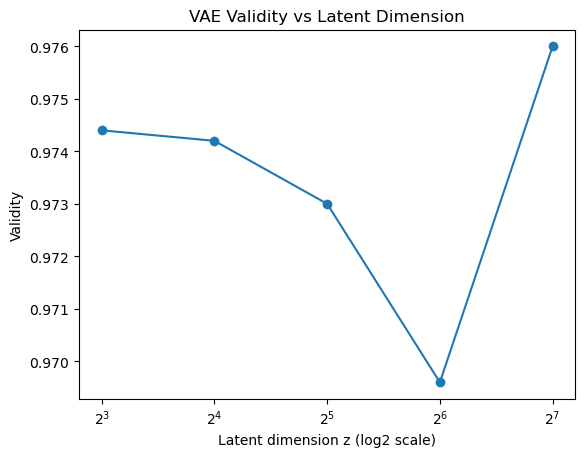

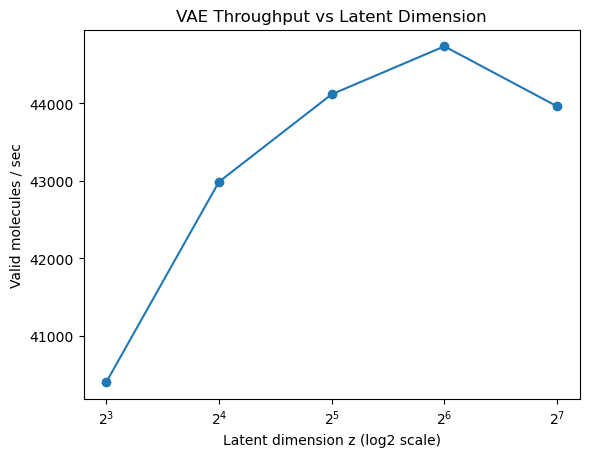

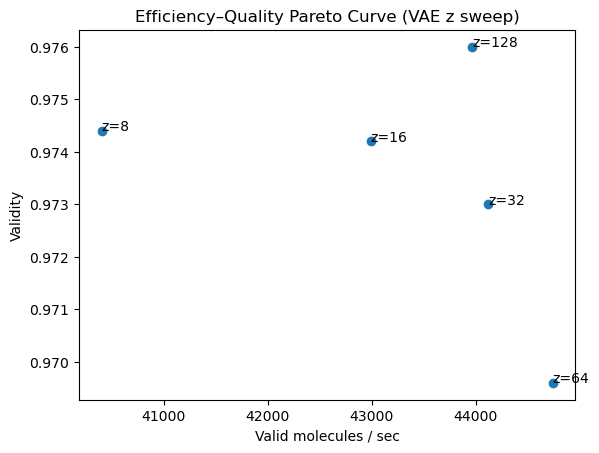

In [11]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["z_dim"], df["validity"], marker="o")
plt.xscale("log", base=2)
plt.xlabel("Latent dimension z (log2 scale)")
plt.ylabel("Validity")
plt.title("VAE Validity vs Latent Dimension")
plt.show()

plt.figure()
plt.plot(df["z_dim"], df["valid_per_sec"], marker="o")
plt.xscale("log", base=2)
plt.xlabel("Latent dimension z (log2 scale)")
plt.ylabel("Valid molecules / sec")
plt.title("VAE Throughput vs Latent Dimension")
plt.show()

plt.figure()
plt.scatter(df["valid_per_sec"], df["validity"])
for _, row in df.iterrows():
    plt.annotate(f"z={int(row['z_dim'])}", (row["valid_per_sec"], row["validity"]))
plt.xlabel("Valid molecules / sec")
plt.ylabel("Validity")
plt.title("Efficiency–Quality Pareto Curve (VAE z sweep)")
plt.show()


In [12]:
out_csv = "./checkpoints/z_sweep_results_qm9.csv"
df.to_csv(out_csv, index=False)
print("Saved:", out_csv)

cols = ["z_dim","validity","uniqueness","novelty","valid_per_sec","final_val_recon","final_val_kl"]
df[cols]


Saved: ./checkpoints/z_sweep_results_qm9.csv


,z_dim,validity,uniqueness,novelty,valid_per_sec,final_val_recon,final_val_kl
0,8,0.9744,0.966544,0.210796,40403.126898,0.803499,5.355699e-07
1,16,0.9742,0.968590,0.215356,42988.315316,0.804671,8.518767e-07
2,32,0.9730,0.962795,0.210894,44117.254370,0.803626,3.910733e-06
3,64,0.9696,0.964315,0.220503,44736.191353,0.803487,2.418624e-06
4,128,0.9760,0.968852,0.219057,43962.240102,0.802927,2.661662e-06
